# General FD Decomposition Walkthrough

This notebook walks through the teaching loop in this repository:

```text
general FD as Horn rules / directed hyperedges
  -> FD closure
  -> candidate keys
  -> compact 3NF synthesis
```

The goal is explanatory rather than novel: make candidate keys and schema decomposition concrete for small examples.

## Setup

The notebook uses this package and the Python standard library. The SVG display cell uses Jupyter's built-in IPython display when available, and falls back to printing the SVG string. The small `sys.path` block lets it run from either the repository root or the `notebooks/` directory.

In [12]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
for module_name in tuple(sys.modules):
    if module_name == "fdkeys" or module_name.startswith("fdkeys."):
        del sys.modules[module_name]

from fdkeys import (
    FD,
    closure,
    explain_3nf_synthesis,
    fd_hypergraph_dot,
    fd_hypergraph_svg,
    find_candidate_keys,
    find_candidate_keys_pruned,
    find_candidate_keys_unary_scc,
    format_fd,
    format_relation,
    is_unary_fds,
    minimal_cover,
    synthesize_3nf,
)

## 1. Project Question

Can candidate keys be viewed as inclusion-minimal seed sets whose FD closure derives all attributes?

We will use a general FD example with left-hand sides containing multiple attributes, including a ternary determinant.

In [13]:
universe = frozenset({"A", "B", "C", "D", "E", "F", "G"})
fds = [
    FD(frozenset({"A", "B", "C"}), "D"),
    FD(frozenset({"D", "E"}), "F"),
    FD(frozenset({"F"}), "G"),
]

print("Universe:", format_relation(universe))
print("FDs:")
for fd in fds:
    print("  ", format_fd(fd))

Universe: {A, B, C, D, E, F, G}
FDs:
   {A, B, C} -> D
   {D, E} -> F
   {F} -> G


## 2. Closure and AND-Semantics

`ABC -> D` means `A`, `B`, and `C` must all be present. It is not equivalent to ordinary graph edges `A -> D`, `B -> D`, and `C -> D`.

In [14]:
for seed in [
    {"A", "B"},
    {"A", "C"},
    {"B", "C"},
    {"A", "B", "C"},
    {"A", "B", "C", "E"},
]:
    print(f"closure({format_relation(seed)}) = {format_relation(closure(seed, fds))}")

closure({A, B}) = {A, B}
closure({A, C}) = {A, C}
closure({B, C}) = {B, C}
closure({A, B, C}) = {A, B, C, D}
closure({A, B, C, E}) = {A, B, C, D, E, F, G}


## 3. Candidate Keys

The baseline search and closure-pruned search should agree. Both return inclusion-minimal seed sets whose closure reaches the whole universe.

In [15]:
baseline_keys = find_candidate_keys(universe, fds)
pruned_keys = find_candidate_keys_pruned(universe, fds)

print("Baseline keys:", [format_relation(key) for key in baseline_keys])
print("Pruned keys:  ", [format_relation(key) for key in pruned_keys])

Baseline keys: ['{A, B, C, E}']
Pruned keys:   ['{A, B, C, E}']


## 4. Directed Hypergraph View

General FDs are displayed as rule nodes. For `ABC -> D`, each prerequisite points into one rule node, and that rule node points to `D`. This preserves AND-semantics.

The first cell renders a dependency-free SVG sketch in Jupyter. The second cell prints Graphviz DOT text for tools that can render DOT.

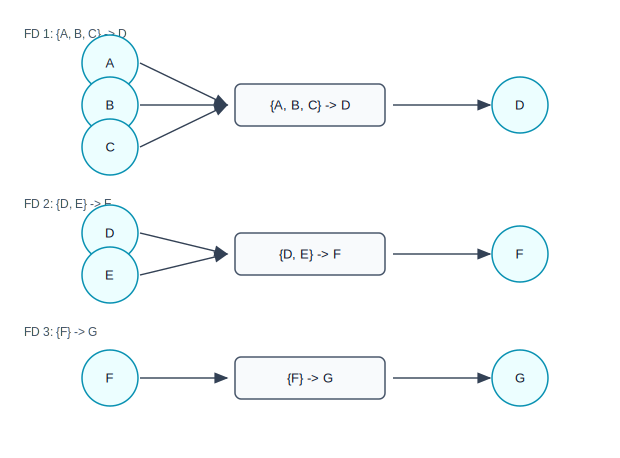

In [16]:
svg = fd_hypergraph_svg(fds)
try:
    from IPython.display import SVG, display

    display(SVG(svg))
except ImportError:
    print(svg)

In [17]:
print(fd_hypergraph_dot(fds))

digraph fd_hypergraph {
  rankdir=LR;
  node [fontname="Arial"];
  edge [fontname="Arial"];
  "A" [shape=ellipse];
  "B" [shape=ellipse];
  "C" [shape=ellipse];
  "D" [shape=ellipse];
  "E" [shape=ellipse];
  "F" [shape=ellipse];
  "G" [shape=ellipse];
  "rule_1" [shape=box, label="{A, B, C} -> D"];
  "A" -> "rule_1";
  "B" -> "rule_1";
  "C" -> "rule_1";
  "rule_1" -> "D";
  "rule_2" [shape=box, label="{D, E} -> F"];
  "D" -> "rule_2";
  "E" -> "rule_2";
  "rule_2" -> "F";
  "rule_3" [shape=box, label="{F} -> G"];
  "F" -> "rule_3";
  "rule_3" -> "G";
}


## 5. Minimal Cover

The 3NF synthesis helper first computes a compact canonical-cover-style FD set. In this example, the original FDs are already compact.

In [18]:
cover = minimal_cover(universe, fds)
for fd in cover:
    print(format_fd(fd))

{A, B, C} -> D
{D, E} -> F
{F} -> G


## 6. 3NF Synthesis Trace

The trace records the generated relations, subsumption cleanup, whether a key relation was added, and the final decomposition.

In [19]:
trace = explain_3nf_synthesis(universe, fds)

print("Generated relations:")
for step in trace.generated_relations:
    determinant = format_relation(step.determinant)
    rhs = ", ".join(step.rhs_attrs)
    relation = format_relation(step.relation)
    print(f"  determinant {determinant}; rhs {{{rhs}}} -> relation {relation}")

print("\nRemoved subsumed relations:", [format_relation(r) for r in trace.removed_subsumed_relations])
print("Relations after subsumption:", [format_relation(r) for r in trace.relations_after_subsumption])
print("Added key relation:", None if trace.added_key_relation is None else format_relation(trace.added_key_relation))
print("Final decomposition:", [format_relation(r) for r in trace.final_relations])

Generated relations:
  determinant {A, B, C}; rhs {D} -> relation {A, B, C, D}
  determinant {D, E}; rhs {F} -> relation {D, E, F}
  determinant {F}; rhs {G} -> relation {F, G}

Removed subsumed relations: []
Relations after subsumption: ['{F, G}', '{D, E, F}', '{A, B, C, D}']
Added key relation: {A, B, C, E}
Final decomposition: ['{F, G}', '{D, E, F}', '{A, B, C, D}', '{A, B, C, E}']


## 7. Final Decomposition

`synthesize_3nf` returns the same final relations as the trace.

In [20]:
decomposition = synthesize_3nf(universe, fds)
assert decomposition == list(trace.final_relations)
for index, relation in enumerate(decomposition, start=1):
    print(f"R{index} = {format_relation(relation)}")

R1 = {F, G}
R2 = {D, E, F}
R3 = {A, B, C, D}
R4 = {A, B, C, E}


## 8. Unary FD Special Case

If every FD has a singleton left-hand side, ordinary directed graph reachability applies. Then candidate keys can be generated by choosing one representative from each source SCC in the condensation DAG. That is a special case, not the model for general FDs.

In [21]:
unary_universe = frozenset({"A", "B", "C", "D"})
unary_fds = [
    FD(frozenset({"A"}), "B"),
    FD(frozenset({"B"}), "A"),
    FD(frozenset({"C"}), "D"),
]

print("All unary?", is_unary_fds(unary_fds))
print("Unary SCC keys:", [format_relation(key) for key in find_candidate_keys_unary_scc(unary_universe, unary_fds)])

All unary? True
Unary SCC keys: ['{A, C}', '{B, C}']


## 9. Normalization Tradeoffs

For BCNF, lossless joins, dependency preservation, and storage-estimate examples, continue with `normalization_tradeoffs.ipynb`.